In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_moons

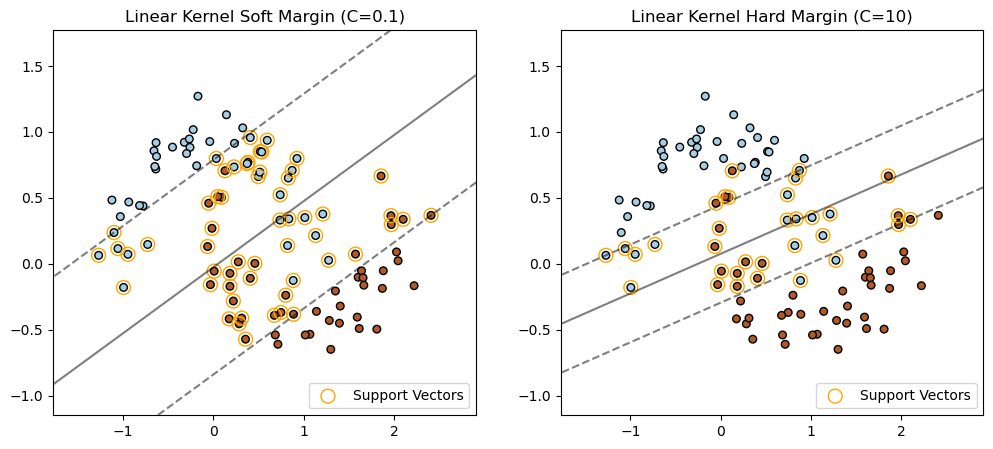

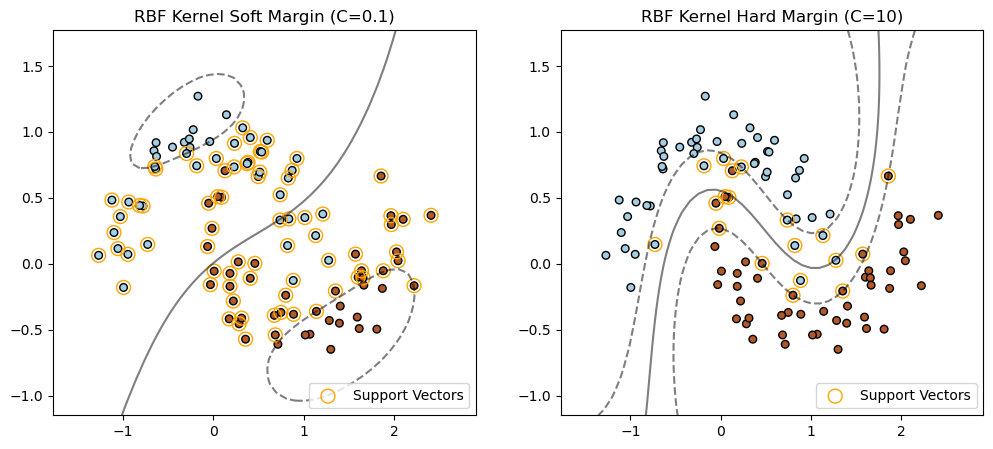

In [3]:

# 1. 产生一份非线性分布的数据 (类似半月形)
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

def plot_svm_comparison(kernel, C_values, titles):
    plt.figure(figsize=(12, 5))
    
    for i, C in enumerate(C_values):
        # 创建并训练 SVM 模型
        # gamma='scale' 是 RBF 核的一个重要参数，决定了单个样本的影响范围
        clf = svm.SVC(kernel=kernel, C=C, gamma=0.5)
        clf.fit(X, y)

        plt.subplot(1, 2, i + 1)
        
        # 绘制背景决策边界
        ax = plt.gca()
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 50),
                             np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 50))
        Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # 绘制等高线：决策边界 (0) 和 间隔边界 (-1, 1)
        ax.contour(xx, yy, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
        
        # 绘制所有样本点
        ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired, edgecolors='k')
        
        # 【核心：绘制支持向量】
        # clf.support_vectors_ 存储了所有被选为支持向量的样本点
        ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
                   linewidth=1, facecolors='none', edgecolors='orange', label='Support Vectors')
        
        plt.title(f"{titles[i]} (C={C})")
        plt.legend(loc='lower right')

# --- 实验 1: 线性核的局限与 C 的影响 ---
# 你会看到线性核无论如何也分不开月牙形数据
plot_svm_comparison('linear', [0.1, 10], ["Linear Kernel Soft Margin", "Linear Kernel Hard Margin"])

# --- 实验 2: 高斯核 (RBF) 的威力与 C 的影响 ---
# 你会看到 RBF 如何弯曲边界，以及 C 如何控制支持向量的数量
plot_svm_comparison('rbf', [0.1, 10], ["RBF Kernel Soft Margin", "RBF Kernel Hard Margin"])

plt.show()